# 05 — Reparto diario del candidato elegido en la comparación climática

(En revisión: desarrollo preliminar y siguientes pasos.) Se conserva el avance y sus resultados; falta profundizar el EDA diario y validar ajustes antes de considerarlo una solución consolidada.

Alcance GAITANA, H1, siete días desde el lunes, información congelada al origen. Se usa la elección de 19 basada en noviembre–diciembre de 2025; no se cambia por el ranking de 2026. Los pesos vienen de 02, ya recalculados con el clima actualizado. La lluvia adicional de 19 influye en el total semanal cuando la alternativa seleccionada la utiliza; este experimento no añade lluvia al modelo que aprende los pesos diarios.

Se compara con el total Memoria_larga actualizado de 04 y con el boosting diario autónomo sobre idénticos días observados. La reconciliación conserva el total pero no garantiza menor error. Los faltantes permanecen faltantes; se muestra sensibilidad de semanas con siete reportes.

La comparación antes/después verifica las mismas fechas, series y producción real; no se atribuye mejora a cambiar la población. Sesgo positivo significa sobreestimación (predicción menos real).

Elección semanal fijada en validación: Sin_clima


,n,WAPE,MAE,RMSE,sesgo,sesgo_pct
modelo,,,,,,
Autonomo_antes_clima,22973.0,0.267642,543.760215,976.617859,-146.885264,-7.229787
Boosting_clima,22973.0,0.272715,554.065371,990.839548,-120.119508,-5.912360
Boosting_diario,22973.0,0.267189,542.839640,974.865466,-144.382353,-7.106592
Boosting_memoria,22973.0,0.274382,557.452844,999.644945,-126.081714,-6.205823
Perfil_clima,22973.0,0.276945,562.660506,1000.776024,-111.420455,-5.484186
Perfil_memoria,22973.0,0.278530,565.879768,1008.770714,-117.497280,-5.783292
Reconciliado_antes_clima,22973.0,0.274543,557.780810,1000.787729,-126.257676,-6.214484
Uniforme_clima,22973.0,0.287924,584.966606,1083.730749,-341.501304,-16.808914
Uniforme_memoria,22973.0,0.290145,589.478864,1095.352043,-346.046078,-17.032611


,n,WAPE,MAE,RMSE,sesgo,sesgo_pct
modelo,,,,,,
Autonomo_antes_clima,1918.0,0.247303,605.520074,995.386108,-188.893620,-7.714669
Boosting_clima,1918.0,0.333256,815.976275,1396.485381,-254.731579,-10.403579
Boosting_diario,1918.0,0.247303,605.520074,995.386108,-188.893620,-7.714669
Boosting_memoria,1918.0,0.337722,826.912737,1403.253366,-197.393057,-8.061797
Perfil_clima,1918.0,0.348526,853.364573,1453.519512,-254.731579,-10.403579
Perfil_memoria,1918.0,0.354770,868.653140,1462.484172,-197.393057,-8.061797
Reconciliado_antes_clima,1918.0,0.337722,826.912737,1403.253366,-197.393057,-8.061797
Uniforme_clima,1918.0,0.248791,609.163986,976.000750,-254.731579,-10.403579
Uniforme_memoria,1918.0,0.245187,600.340186,944.208074,-197.393057,-8.061797


,n,WAPE,MAE,RMSE,sesgo,sesgo_pct
modelo,,,,,,
Autonomo_antes_clima,19411.0,0.267565,594.294601,1041.201593,-159.576330,-7.184496
Boosting_clima,19411.0,0.269551,598.706190,1043.891411,-139.267693,-6.270154
Boosting_diario,19411.0,0.267094,593.247549,1039.272368,-156.755732,-7.057506
Boosting_memoria,19411.0,0.270771,601.414283,1052.072363,-148.137630,-6.669499
Perfil_clima,19411.0,0.273575,607.643842,1053.474346,-129.911770,-5.848929
Perfil_memoria,19411.0,0.274650,610.029884,1060.640902,-138.912538,-6.254164
Reconciliado_antes_clima,19411.0,0.270945,601.801947,1053.360458,-148.388924,-6.680813
Uniforme_clima,19411.0,0.289096,642.117746,1159.993954,-385.833031,-17.371097
Uniforme_memoria,19411.0,0.291200,646.791166,1172.503283,-393.062288,-17.696575


,referencia,ventaja_Boosting_clima_pp,p025,p975
0,Reconciliado_antes_clima,0.182876,-0.104644,0.530125
1,Boosting_memoria,0.166734,-0.119128,0.479270
2,Boosting_diario,-0.552538,-1.786848,0.679224
3,Uniforme_clima,1.520979,-0.200666,3.059326


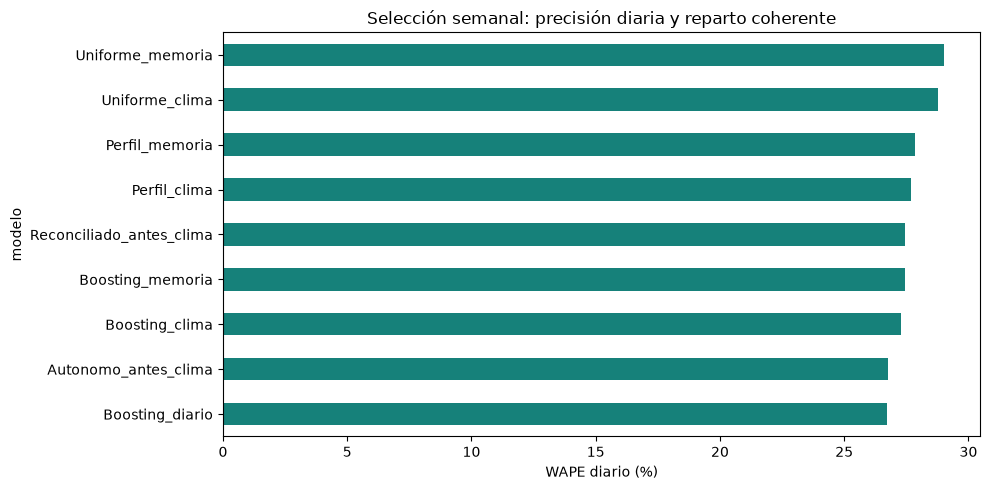

Intervalos exploratorios por semana de origen. No hay benchmark diario del ingeniero ni validación prospectiva intacta.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos_analiticos_proyecto').exists())
DATA=ROOT/'Datos_analiticos_proyecto';D=DATA/'modelo_diario';OUT=DATA/'revision_clima_finca'
KEY=['finca','producto','color','variedad'];WK=KEY+['origen']
pred=pd.read_parquet(D/'predicciones_diarias_memoria_2026.parquet')
s=pd.read_parquet(OUT/'comparacion_clima_curvas_2026.parquet');s=s.loc[s.horizonte.eq(1)]
assert s.modelo_seleccionado.nunique()==1
eleccion=s.modelo_seleccionado.iloc[0]
pred=pred.merge(s[WK+['Seleccion_pre2026','modelo_seleccionado']],on=WK,how='left',validate='many_to_one')
assert pred.Seleccion_pre2026.notna().all()
pred['Uniforme_clima']=pred.Seleccion_pre2026/7
pred['Perfil_clima']=pred.Seleccion_pre2026*pred.peso_perfil
pred['Boosting_clima']=pred.Seleccion_pre2026*pred.peso_boost
antes=pd.read_parquet(OUT/'diario_antes_clima.parquet')
antes=antes[WK+['fecha','tallos','Boosting_diario','Boosting_memoria']].rename(columns={'tallos':'real_anterior','Boosting_diario':'Autonomo_antes_clima','Boosting_memoria':'Reconciliado_antes_clima'})
pred=pred.merge(antes,on=WK+['fecha'],how='left',validate='one_to_one')
assert len(pred)==len(antes) and np.allclose(pred.tallos,pred.real_anterior,equal_nan=True)
metodos=['Autonomo_antes_clima','Reconciliado_antes_clima','Boosting_diario','Uniforme_memoria','Perfil_memoria','Boosting_memoria','Uniforme_clima','Perfil_clima','Boosting_clima']
for m in ['Uniforme_clima','Perfil_clima','Boosting_clima']:
    assert np.allclose(pred.groupby(WK)[m].sum(),pred.groupby(WK).Seleccion_pre2026.first())
assert np.isfinite(pred[metodos]).all().all() and pred[metodos].ge(0).all().all()
print('Elección semanal fijada en validación:',eleccion)
obs=pred.loc[pred.tallos.notna()]
long=obs.melt(id_vars=WK+['fecha','dia_objetivo','tallos','semana_completa','grupo_comparacion'],value_vars=metodos,var_name='modelo',value_name='prediccion')
def evaluar(g):
    e=g.tallos-g.prediccion
    return pd.Series({'n':len(g),'WAPE':e.abs().sum()/g.tallos.sum(),'MAE':e.abs().mean(),'RMSE':np.sqrt((e**2).mean()),'sesgo':-e.mean(),'sesgo_pct':-100*e.sum()/g.tallos.sum()})
resumen=long.groupby('modelo').apply(evaluar)
por_dia=long.groupby(['dia_objetivo','modelo']).apply(evaluar)
completas=long.loc[long.semana_completa].groupby('modelo').apply(evaluar)
estricto=long.loc[long.grupo_comparacion.eq('principal_estricta_nominal')].groupby('modelo').apply(evaluar)
display(resumen);display(completas);display(estricto)
rng=np.random.default_rng(42);rows=[]
for ref in ['Reconciliado_antes_clima','Boosting_memoria','Boosting_diario','Uniforme_clima']:
    z=obs.assign(ventaja=(obs.tallos-obs[ref]).abs()-(obs.tallos-obs.Boosting_clima).abs()).groupby('origen')[['ventaja','tallos']].sum()
    ix=rng.integers(0,len(z),(1000,len(z)));v=100*z.ventaja.to_numpy()[ix].sum(axis=1)/z.tallos.to_numpy()[ix].sum(axis=1)
    rows.append({'referencia':ref,'ventaja_Boosting_clima_pp':100*z.ventaja.sum()/z.tallos.sum(),'p025':np.quantile(v,.025),'p975':np.quantile(v,.975)})
intervalos=pd.DataFrame(rows);display(intervalos)
pred.to_parquet(D/'predicciones_diarias_clima_2026.parquet',index=False)
with pd.ExcelWriter(D/'resultados_diarios_clima.xlsx') as w:
    for nombre,t in [('Resumen',resumen),('Dia_semana',por_dia),('Semanas_completas',completas),('Panel_estricto',estricto),('Incertidumbre',intervalos)]:t.to_excel(w,sheet_name=nombre)
fig,ax=plt.subplots(figsize=(10,5));resumen.WAPE.sort_values().mul(100).plot.barh(ax=ax,color='#16817a');ax.set_xlabel('WAPE diario (%)');ax.set_title('Selección semanal: precisión diaria y reparto coherente');fig.tight_layout();fig.savefig(ROOT/'Trabajo escrito/Figuras_resultados/diario_clima_actualizado.png',dpi=170);plt.show()
print('Intervalos exploratorios por semana de origen. No hay benchmark diario del ingeniero ni validación prospectiva intacta.')

## Train y test del mismo ajuste, y piloto temporal

El entrenamiento compuesto usa los pronósticos semanales dentro de muestra del último ajuste de 19 y los pesos/boosting dentro de muestra de 17. No es un backtest emitido en esas fechas. Su test corresponde únicamente a agosto; no se resta de la evaluación acumulada como si fueran el mismo corte. Para el piloto se mantiene el SARIMA/SARIMAX autónomo ya ajustado, cambiando sólo el total de reconciliación.

In [2]:
ht=pd.read_parquet(D/'componentes_train_diario_ultimo_ajuste.parquet')
st=pd.read_parquet(OUT/'predicciones_train_h1_ultimo_ajuste.parquet')
st=st.loc[st.modelo.eq(eleccion)]
assert st.corte.nunique()==1 and ht.corte.eq(st.corte.iloc[0]).all()
n_antes=len(ht)
ht=ht.merge(st[WK+['prediccion_train']],on=WK,how='left',validate='many_to_one')
assert len(ht)==n_antes and ht.prediccion_train.notna().all()
ht['Uniforme_clima']=ht.prediccion_train/7
ht['Perfil_clima']=ht.prediccion_train*ht.peso_perfil
ht['Boosting_clima']=ht.prediccion_train*ht.peso_boost
for metodo in ['Uniforme_clima','Perfil_clima','Boosting_clima']:
    assert np.allclose(ht.groupby(WK)[metodo].sum(),ht.groupby(WK).prediccion_train.first())
tt=[];corte=st.corte.iloc[0]
for split,t in [('train',ht.loc[ht.tallos.notna()]),('test',pred.loc[pred.origen.dt.to_period('M').eq(corte.to_period('M'))&pred.tallos.notna()])]:
    for metodo in ['Boosting_diario','Uniforme_clima','Perfil_clima','Boosting_clima']:
        z=t.assign(prediccion=t[metodo]);tt.append({'modelo':metodo,'split':split,'corte':corte}|evaluar(z).to_dict())
train_test=pd.DataFrame(tt);display(train_test)
pilot=pd.read_parquet(D/'comparacion_sarima_diaria.parquet')
pilot=pilot.merge(pred[WK+['fecha','Seleccion_pre2026','Uniforme_clima','Perfil_clima','Boosting_clima']],on=WK+['fecha'],how='left',validate='one_to_one')
for metodo in ['SARIMA','SARIMAX']:
    total=pilot.groupby(WK)[metodo].transform('sum');ok=pilot.groupby(WK)[metodo].transform('count').eq(7)&total.gt(0)
    pilot[metodo+'_clima']=np.where(ok,pilot[metodo]/total*pilot.Seleccion_pre2026,np.nan)
met_p=['Semana_anterior','SARIMA','SARIMAX','Boosting_diario','Uniforme_clima','Perfil_clima','Boosting_clima','SARIMA_clima','SARIMAX_clima']
pilot_ok=pilot.loc[pilot.tallos.notna()&pilot[met_p].notna().all(axis=1)]
lp=pilot_ok.melt(id_vars=WK+['fecha','tallos'],value_vars=met_p,var_name='modelo',value_name='prediccion')
res_p=lp.groupby('modelo').apply(evaluar);display(res_p)
with pd.ExcelWriter(D/'resultados_diarios_clima.xlsx',mode='a',engine='openpyxl',if_sheet_exists='replace') as w:
    train_test.to_excel(w,sheet_name='Train_test_ultimo_ajuste',index=False)
    res_p.to_excel(w,sheet_name='Piloto_SARIMA')
pilot.to_parquet(D/'piloto_sarima_clima.parquet',index=False)
print('Verificados entrenamiento compuesto y muestras comunes del piloto. Sus resultados no se extrapolan a toda la finca.')

,modelo,split,corte,n,WAPE,MAE,RMSE,sesgo,sesgo_pct
0,Boosting_diario,train,2026-08-03,70448.0,0.258980,458.859637,812.282682,-105.321602,-5.944350
1,Uniforme_clima,train,2026-08-03,70448.0,0.286986,508.480180,917.179819,-263.380025,-14.865165
2,Perfil_clima,train,2026-08-03,70448.0,0.274095,485.639952,839.223329,-53.621590,-3.026402
3,Boosting_clima,train,2026-08-03,70448.0,0.265722,470.804183,812.445760,-67.368834,-3.802296
4,Boosting_diario,test,2026-08-03,3192.0,0.266462,528.099682,1010.172732,-175.823155,-8.871478
5,Uniforme_clima,test,2026-08-03,3192.0,0.309477,613.349327,1220.673224,-387.799706,-19.567141
6,Perfil_clima,test,2026-08-03,3192.0,0.273181,541.415741,970.892223,-117.791227,-5.943371
7,Boosting_clima,test,2026-08-03,3192.0,0.272466,539.997571,990.982940,-134.022252,-6.762337


,n,WAPE,MAE,RMSE,sesgo,sesgo_pct
modelo,,,,,,
Boosting_clima,135.0,0.271301,2452.888770,3337.509117,-1054.989783,-11.668692
Boosting_diario,135.0,0.308805,2791.971717,3694.313256,-1132.515580,-12.526164
Perfil_clima,135.0,0.270272,2443.587035,3342.365396,-1073.790520,-11.876637
SARIMA,135.0,0.249094,2252.108548,3060.919575,-235.593344,-2.605775
SARIMAX,135.0,0.245289,2217.704806,3048.749995,-269.218344,-2.977684
SARIMAX_clima,135.0,0.298706,2700.659015,3719.026174,-1978.877617,-21.887334
SARIMA_clima,135.0,0.297041,2685.610068,3690.258456,-1968.585676,-21.773500
Semana_anterior,135.0,0.314112,2839.949850,3912.705928,-259.541937,-2.870658
Uniforme_clima,135.0,0.295998,2676.175394,3737.464775,-2011.318120,-22.246141


Verificados entrenamiento compuesto y muestras comunes del piloto. Sus resultados no se extrapolan a toda la finca.
